In [1]:
from modules import *
# from pluma.schema.outdoor import build_schema
import maat_schema as maat
import pluma.schema.outdoor as outdoor
import missing_sync as missing_sync

%matplotlib widget

In [ ]:
data_path  = r'Z:\Exp_4-outdoor_walk\london\sourcedata\data\OE309001\London_NottingHill_sub-OE309001'
datapicker = create_datapicker(schema=build_schema)
datapicker.reset(path = data_path)
dataset = load_dataset(datapicker.selected_path,schema=build_schema, calibrate_ubx_to_harp=False)
geodata = dataset.to_geoframe()


### 1. Load dataset

FileChooser(path='\\nas-emotional.fm.ul.pt\eMotional\Exp_4-outdoor_walk\lisbon\sourcedata\data\OE078', filenam…

Loading dataset: Lisbon_Maat_sub-OE123078_2025-02-06T120336Z...
Attempting to automatically correct eeg timestamps to harp timestamps...
Done.
Dataset: <pluma.schema.Dataset object at 0x0000024923C84E50> loaded successfully, and sucessfully calibrated.


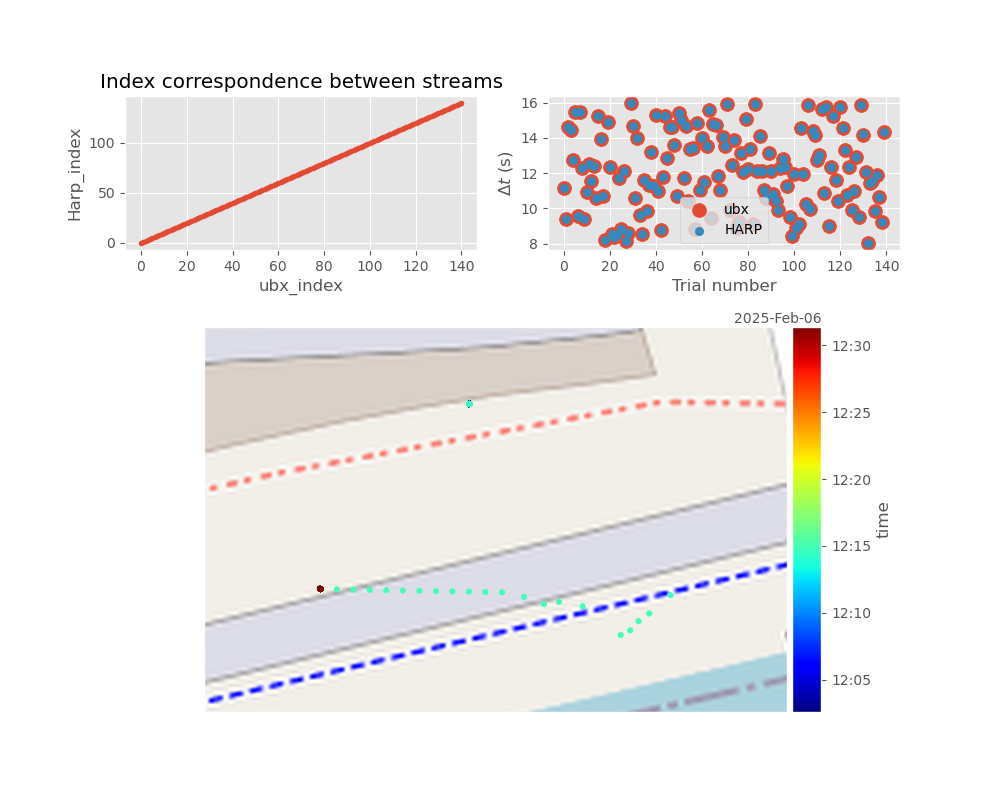

Failed Stream Harp stream from device 		TK, stream GPS_Latitude(227): Input dataframe is empty.
Failed Stream Harp stream from device 		TK, stream GPS_Longitude(228): Input dataframe is empty.
Failed Stream Harp stream from device 		TK, stream GPS_Altitude(229): Input dataframe is empty.
Failed Stream Harp stream from device 		TK, stream GPS_HasFix(232): Input dataframe is empty.


In [3]:
data_path  = r'Z:\Exp_4-outdoor_walk\lisbon\sourcedata\data\OE078'
datapicker = create_datapicker(path=data_path, schema=maat.build_schema,  calibrate_ubx_to_harp=True)
display(datapicker)

### 2. Explore Dataset Maps

In [ ]:
exploremap(datapicker.geodata, column='tk_airquality_iaqindex_value')

In [ ]:
datapicker.dataset.streams.Empatica.data['E4_Gsr']

### 3. Explore Dataset Streams

In [ ]:
plot_traces({
    'accelX': datapicker.dataset.streams.Accelerometer.data["Accl_X"],
    'temp (C)': datapicker.dataset.streams.TK.AirQuality.Temperature.data/100,
    'angleX': datapicker.dataset.streams.Accelerometer.data["Orientation_X"],
    'altitude': datapicker.dataset.georeference.elevation,
    'iaq': datapicker.dataset.streams.TK.AirQuality.IAQIndex.data,
})

### 4. Export Dataset to OGC API

In [ ]:
record = DatasetRecord(datapicker.dataset, datapicker.geodata, properties=RecordProperties(
    title='<City> Outdoor Walk: <CityRegion> Subject <ID>',
    description='Outdoor walk data collection',
    license='CC BY-NC 4.0',
    tool='Bonsai',
    keywords=['<City>', 'Outdoor', 'Walk', 'Microclimate', 'Biosignals'],
    contacts=[
        Contact(
            name='Your Name',
            institution='Your Institution',
            email='youremail@yourdomain.com'
        )
    ],
    themes=[]
))

In [ ]:
rpath = Path(record.id)
export_geoframe_to_geojson(datapicker.geodata, rpath.with_suffix('.geojson'))
with open(rpath.with_suffix('.json'), 'w') as f:
    f.write(record.to_json())